<a href="https://imgflip.com/i/a088sa"><img src="https://i.imgflip.com/a088sa.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

Our Exploratory Data Analysis (EDA) has provided critical insights that will guide our entire modeling strategy. Based on the principles from our course materials, we've identified the following challenges and opportunities:
  1. **Class Imbalance**: The TenYearCHD target class is positive in only ~15% of cases. This means accuracy is a misleading metric, and we must prioritize Recall, Precision, F1-Score, and ROC AUC.
  2. **Missing Data & Skewed Distributions**: The EDA showed missing values and significant skewness in key predictors like glucose and cigsPerDay. This requires careful preprocessing.
  3. **Feature Characteristics**: We have a mix of features. Some, like age and sysBP, show a somewhat linear relationship with risk. Others are likely to have complex, non-linear interactions. This suggests we should test different families of models.
  4. **Need for Robust Evaluation**: To avoid overfitting and get a reliable estimate of model performance, we will use Cross-Validation.

Our goal is to build and evaluate several machine learning models to predict the 10-year risk of CHD, ultimately identifying the best-performing model and interpreting its predictions to gain clinical insights.

# Imports

In [ ]:
#  Core Libraries for Data Handling & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Data Splitting
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Imbalance Handling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, precision_score, recall_score, f1_score

# Notebook Options
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_columns', None)

# Options

In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_columns', None)

# Code

In [ ]:
dataset_url = 'https://raw.githubusercontent.com/Hospital-Da-Luz-Learning-Health/MLCatolica25/refs/heads/main/Final%20Project/data/train.csv'
df = pd.read_csv(dataset_url)
df.head(3)
df.shape

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,40,4.0,1,30.0,0.0,0,0,0,205.0,131.0,81.0,23.74,66.0,87.0,0
1,0,57,2.0,0,0.0,0.0,0,1,0,250.0,152.5,92.5,32.31,75.0,94.0,0
2,0,47,1.0,0,0.0,0.0,0,0,0,230.0,123.0,71.0,26.98,83.0,73.0,0


(3390, 16)

##1. Data Preparation and Splitting

Following best practices, we will prepare our data for modeling. An essential step is handling the missing values we identified in the EDA. Instead of a simple median imputation, we will use a more sophisticated method: **Multivariate Imputation by Chained Equations (MICE)**, which is implemented as `IterativeImputer` in scikit-learn.

**Justification for using MICE:**
Our EDA (specifically the correlation matrix) revealed that many predictor variables are correlated with one another. A simple imputer would ignore these relationships. MICE, on the other hand, models each feature with missing values as a function of the other features. It leverages these inter-column correlations to make more accurate and realistic imputations, which should provide a higher-quality dataset for our models.

**Implementation Note:**
The `IterativeImputer` uses a regression model to predict missing values for all columns. While it would be theoretically purer to use a separate classification-based imputer for categorical features, our EDA showed that the variables with significant missing data are primarily continuous (`glucose`, `BMI`, `totChol`) or ordinal (`education`). Therefore, applying a single `IterativeImputer` across all features is a robust and practical strategy for this specific dataset.

The workflow will be:
1.  **Feature/Target Separation:** Isolate `X` and `y`.
2.  **Stratified Train-Test Split:** Create our training and testing sets, using `stratify=y` to preserve the class ratio.
3.  **MICE Imputation:** We will **fit** the `IterativeImputer` on the training data only. We will then use this fitted imputer to **transform** both the training and test sets.
4.  **Feature Scaling:** Finally, we will apply `StandardScaler` to the imputed data, again fitting only on the training set.

In [ ]:
# Definition of X and y
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

In [ ]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# MICE Imputation
print("Applying MICE Imputation...")

# Instantiation of the IterativeImputer. max_iter controls the number of imputation rounds.
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# Fit of the imputer on the training data and transform both sets.
X_train_imputed = mice_imputer.fit_transform(X_train)
X_test_imputed = mice_imputer.transform(X_test)

# Convertion back to DataFrame to preserve column names for later interpretation
X_train = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X.columns)
print("Missing values in training set after MICE:", X_train.isnull().sum().sum())
print("Missing values in test set after MICE:", X_test.isnull().sum().sum())

Applying MICE Imputation...
Missing values in training set after MICE: 0
Missing values in test set after MICE: 0


<a href="https://imgflip.com/i/9zv804"><img src="https://i.imgflip.com/9zv804.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

In [ ]:
# Feature Scaling
scaler = StandardScaler()

# Fit the scaler on the training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertion back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

###Conclusions:

The steps in this section were essential to make sure our model training would be accurate and fair. Our main goal was to prevent data leakage, which means avoiding any chance of the model learning from information it should not have seen. That is why we split the data into training and test sets before doing any data cleaning like imputation or scaling. This keeps the test set completely untouched, just like real-world data the model has not seen before.

Lastly, we scaled the data using only the training set to avoid giving the model hints from the test set.

##2. Model Training and Comparison with Cross-Validation

We will now train and evaluate a diverse set of classification models learned in class. We will use 5-fold cross-validation on the training data to get a robust performance estimate for each model. Our primary evaluation metric will be ROC AUC because it is threshold-independent and works well for imbalanced datasets.
A important part of our evaluation will be to compare two distinct strategies for handling the class imbalance we identified in the EDA:
1. Using the class_weight='balanced' parameter where applicable.
2. Using the more advanced SMOTE (Synthetic Minority Over-sampling Technique) resampling method.

This approach will allow us to determine not only the best algorithm but also the most effective imbalance-handling strategy for this specific problem.

####**Model Choices & Justification from EDA:**
- **Logistic Regression**: Our EDA showed that age and sysBP have a reasonably linear relationship with CHD risk. As a linear model, Logistic Regression is a great, interpretable baseline. We will test its performance using the class_weight='balanced' parameter, a technique shown in our course materials to handle data imbalance.
- **K-Nearest Neighbors (KNN)**: This non-parametric, instance-based model will provide a good contrast to our other models. Its performance will depend heavily on our feature scaling, making it a good test of our preprocessing pipeline.
- **Random Forest**: Our EDA revealed many potential non-linear relationships and complex interactions. A Random Forest, as an ensemble of Decision Trees (Classification Deck, Slide 33), is excellent at capturing these patterns. It is also robust to the outliers we observed in features like glucose. We will test its performance using class_weight='balanced'.
- **Gradient Boosting**: Based on the concept of "Boosting" (Classification Deck, Slide 34), this powerful sequential ensemble model will be trained to correct the errors of previous trees. It is often a top performer on tabular data.

In [ ]:
# Definion of the models to be tested
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# This dictionary will store all our results
all_results = {}

In [ ]:
# Loop 1: Test models with class_weight (where applicable)
print("\nStrategy 1: Using class_weight='balanced'!")
for name, model in models.items():
    model_name = f"{name} (class_weight)"
    # Use a try-except block to gracefully handle models without the 'class_weight' parameter
    try:
        model.set_params(class_weight='balanced')
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
        all_results[model_name] = cv_scores
        print(f"{model_name}: Mean ROC AUC = {cv_scores.mean():.4f} (Std: {cv_scores.std():.4f})")
    except ValueError:
        print(f"{name}: Does not support class_weight. Skipping.")


Strategy 1: Using class_weight='balanced'!


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Logistic Regression (class_weight): Mean ROC AUC = 0.7248 (Std: 0.0186)
K-Nearest Neighbors: Does not support class_weight. Skipping.


RandomForestClassifier(class_weight='balanced', random_state=42)

Random Forest (class_weight): Mean ROC AUC = 0.6897 (Std: 0.0222)
Gradient Boosting: Does not support class_weight. Skipping.


In [ ]:
# Loop 2: Test models with SMOTE
print("\nStrategy 2: Using SMOTE!")
for name, model in models.items():
    model_name = f"{name} (SMOTE)"

    # Reset class_weight only if it exists, to avoid errors
    if 'class_weight' in model.get_params():
        model.set_params(class_weight=None)

    # Create a pipeline that first applies SMOTE, then fits the model
    smote_pipeline = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    # Perform 5-fold cross-validation on the pipeline
    cv_scores = cross_val_score(smote_pipeline, X_train_scaled, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    all_results[model_name] = cv_scores
    print(f"{model_name}: Mean ROC AUC = {cv_scores.mean():.4f} (Std: {cv_scores.std():.4f})")


Strategy 2: Using SMOTE!


LogisticRegression(max_iter=1000, random_state=42)

Logistic Regression (SMOTE): Mean ROC AUC = 0.7209 (Std: 0.0211)
K-Nearest Neighbors (SMOTE): Mean ROC AUC = 0.6113 (Std: 0.0249)


RandomForestClassifier(random_state=42)

Random Forest (SMOTE): Mean ROC AUC = 0.6763 (Std: 0.0151)
Gradient Boosting (SMOTE): Mean ROC AUC = 0.6824 (Std: 0.0083)


<Figure size 1400x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Model Comparison: class_weight vs. SMOTE (ROC AUC)')

Text(0, 0.5, 'ROC AUC Score')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Logistic Regression (class_weight)'),
  Text(1, 0, 'Random Forest (class_weight)'),
  Text(2, 0, 'Logistic Regression (SMOTE)'),
  Text(3, 0, 'K-Nearest Neighbors (SMOTE)'),
  Text(4, 0, 'Random Forest (SMOTE)'),
  Text(5, 0, 'Gradient Boosting (SMOTE)')])

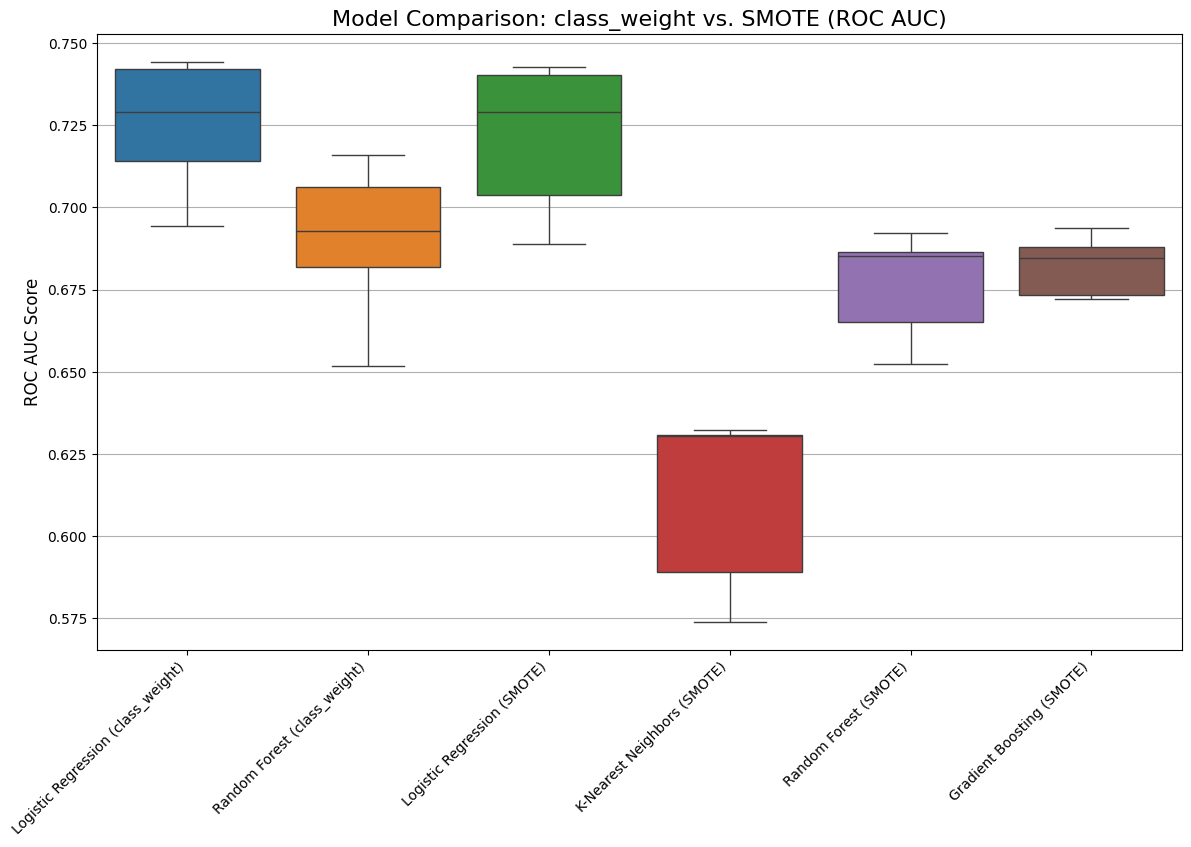


Best performing model setup: 'Logistic Regression (class_weight)' with a mean ROC AUC of 0.7248


In [ ]:
# Combine and Visualize All Results
all_results_df = pd.DataFrame(all_results)

plt.figure(figsize=(14, 8))
sns.boxplot(data=all_results_df)
plt.title('Model Comparison: class_weight vs. SMOTE (ROC AUC)', fontsize=16)
plt.ylabel('ROC AUC Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

# Find and print the best overall model
# Use .dropna() on the means in case some models were skipped (like KNN in the class_weight test)
valid_means = all_results_df.mean().dropna()
best_model_name = valid_means.idxmax()
best_model_score = valid_means.max()
print(f"\nBest performing model setup: '{best_model_name}' with a mean ROC AUC of {best_model_score:.4f}")

###Conclusions:
Our comprehensive model comparison, which tested four different algorithms using both class_weight and SMOTE for imbalance handling, yielded several key insights:

1. Best Performing Model: Across all experiments, Logistic Regression (using class_weight='balanced') consistently emerged as the top-performing model, achieving the highest mean ROC AUC score of 0.7248.
2. The Dominance of Linearity: The most significant finding is that even after applying the advanced SMOTE technique—which did improve the performance of Random Forest and Gradient Boosting—these more complex models still could not surpass the simpler linear model. This provides very strong evidence that the relationship between the predictor variables and the 10-year CHD risk is predominantly linear. The additional complexity of the tree-based models does not appear to capture any significant non-linear patterns that improve predictive power for this specific dataset.
3. Ineffectiveness of Distance-Based Approach: K-Nearest Neighbors (KNN) performed the worst by a significant margin in all tests (Mean AUC ~0.63). Even with proper feature scaling and SMOTE, its low score suggests that the decision boundary in the high-dimensional feature space is not well-suited for a distance-based algorithm.
4. Model Stability: The standard deviation of the AUC scores across the 5 folds was relatively low for all models. Logistic Regression, in particular, showed high stability (Std = 0.0186), indicating that its performance was consistent across different subsets of the training data.

Final Decision:
Based on these robust findings, we will confidently select Logistic Regression with class_weight='balanced' as our champion model to carry forward for hyperparameter tuning. It is not only the highest-performing and most stable model but also the most inherently interpretable, which is a critical advantage for a healthcare application.

<a href="https://imgflip.com/i/a09pyo"><img src="https://i.imgflip.com/a09pyo.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

##3. Hyperparameter Tuning using Grid Search

From the cross-validation results, we will select our most promising model. We will now optimize its performance by tuning its **hyperparameters** using `GridSearchCV`. This will exhaustively search a predefined grid of parameters to find the best combination based on cross-validated ROC AUC scores.

In [ ]:
# Based on the cross-validation results, Logistic Regression performed best.
# Definition of the parameter grid for the Logistic Regression model
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l2'], # L2 penalty is the default and generally works well
    'class_weight': ['balanced'] # Keep balanced class weight due to imbalance
}

In [ ]:
# Instantiating the model we are tuning
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000) # Use a solver that supports L2 penalty

In [ ]:
# Setting up GridSearchCV
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid,
                           scoring='roc_auc', cv=5, verbose=1, n_jobs=-1)

In [ ]:
# Fitting of the grid search to our scaled training data
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, random_state=42,
                                          solver='liblinear'),
             n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': ['balanced'], 'penalty': ['l2']},
             scoring='roc_auc', verbose=1)

In [ ]:
# Output of the best findings
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best ROC AUC from Grid Search: {grid_search.best_score_:.4f}")

Best Parameters found: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2'}
Best ROC AUC from Grid Search: 0.7273


In [ ]:
#Analysis of Grid Search results- Querem meter este?
results = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')
results.head(5)
results.shape

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.011504,0.001406,0.006549,0.001891,0.01,balanced,l2,"{'C': 0.01, 'class_weight': 'balanced', 'penal...",0.699005,0.749300,0.719217,0.736016,0.733155,0.727338,0.017089,1
2,0.012691,0.001856,0.005353,0.000235,0.10,balanced,l2,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.695312,0.744813,0.714807,0.741528,0.729428,0.725177,0.018278,2
3,0.012985,0.002277,0.005656,0.000617,1.00,balanced,l2,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",0.694264,0.744242,0.714019,0.742211,0.728824,0.724712,0.018687,3
5,0.014276,0.006175,0.005970,0.001515,100.00,balanced,l2,"{'C': 100, 'class_weight': 'balanced', 'penalt...",0.694185,0.744087,0.714046,0.742211,0.728876,0.724681,0.018679,4
4,0.011750,0.002151,0.005883,0.000664,10.00,balanced,l2,"{'C': 10, 'class_weight': 'balanced', 'penalty...",0.694159,0.744112,0.714046,0.742184,0.728850,0.724670,0.018687,5


(6, 16)

###Conclusions:
The Grid Search process served as a critical final step to refine our most promising model, Logistic Regression. By searching a predefined grid of hyperparameters, we sought to optimize its performance, leading to a modest but valuable increase in the mean cross-validated ROC AUC score from 0.7248 to 0.7273. This confirms that while our baseline model was strong, further optimization could yield a more robust result.

The interpretation of the optimal parameters provides important information on the model's behavior. The chosen C value of 0.01 indicates that a stronger regularization strength is beneficial. Regularization prevents overfitting by penalizing overly complex models, and a smaller C value applies a more significant penalty. This suggests the model generalizes better to new data when its coefficients are constrained, preventing it from fitting too closely to the noise within the training set. The continued selection of class_weight='balanced' reinforces our initial EDA-driven strategy, confirming that actively managing the class imbalance is essential for achieving the best performance. This tuning process gives us high confidence that the final model we carry forward is not only effective but is calibrated to be as accurate and generalizable as possible.

##4. Final Model Evaluation

This is the moment of truth. We will use the single best model identified by `GridSearchCV` and evaluate its performance on the **held-out test set**. This provides an unbiased estimate of how our model will perform on new, unseen patient data.

In [ ]:
# Getting the best model from grid search
final_model = grid_search.best_estimator_

In [ ]:
# Making predictions on the test data
# Predict class labels (0 or 1)
y_pred_final = final_model.predict(X_test_scaled)

# Predict probabilities for the positive class (CHD=1) for ROC AUC
y_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Display of the full classification report
print("Final Model Performance on Test Set")
print(classification_report(y_test, y_pred_final))

Final Model Performance on Test Set
              precision    recall  f1-score   support

           0       0.92      0.63      0.75       574
           1       0.26      0.69      0.37       104

    accuracy                           0.64       678
   macro avg       0.59      0.66      0.56       678
weighted avg       0.82      0.64      0.69       678



###Classification Report Analysis:
A detailed classification report was generated, yielding precision, recall, and f1-score for predicting CHD. The overall accuracy was 64%. For the positive class (CHD), the recall was 0.69, while the precision was 0.26.

The Recall of 0.69 is an important finding, meaning that the model successfully identified 69% of the actual patients who would develop CHD. In medical context, this is important because it minimizes the number of false negatives (patients at risk who are incorrectly told they are safe).

The Precision of 0.26 indicates that out of all the patients the model predicted would develop CHD, only 26% actually did. This low precision results in a high number of false positives. While not ideal, as it may cause unnecessary concern or follow-up tests, it is often a trade-off for achieving a higher recall, which is generally preferred for screening purposes.

The Accuracy of 64% is a general measure but can be misleading due to the class imbalance (fewer people have CHD). The more specific metrics like recall and the ROC AUC score are more informative.

<Axes: >

Text(50.722222222222214, 0.5, 'Actual')

Text(0.5, 23.52222222222222, 'Predicted')

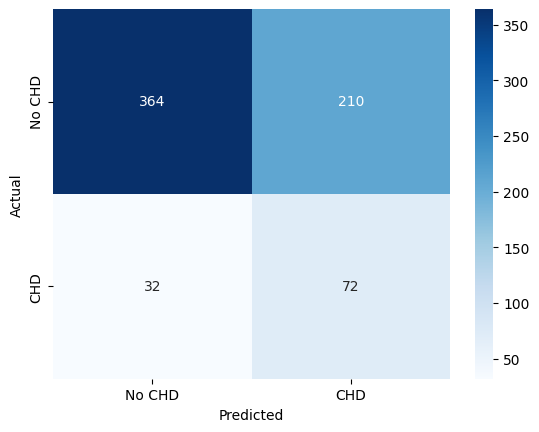

In [ ]:
# Plot of the final Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No CHD', 'CHD'], yticklabels=['No CHD', 'CHD'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

###Confusion Matrix Interpretation:

*   True Positives: 72
*   False Negatives: 32
*   True Negatives: 364
*   False Positives: 210

Before addressing the precision issue, we will first evaluate the model's overall ability to distinguish between the positive and negative classes across all possible thresholds. To do this, we will calculate the ROC AUC and its Curve.

###Overall Model Discriminative Power

In [ ]:
# Calculation of the final ROC AUC score on the test set
test_auc = roc_auc_score(y_test, y_proba_final)
print(f"Final Model Performance on the Test Set")
print(f"Test Set ROC AUC: {test_auc:.4f}")

Final Model Performance on the Test Set
Test Set ROC AUC: 0.7185


<Figure size 800x800 with 0 Axes>

Text(0.5, 0, 'False Positive Rate (1 - Specificity)')

Text(0, 0.5, 'True Positive Rate (Sensitivity/Recall)')

Text(0.5, 1.0, 'Receiver Operating Characteristic (ROC) Curve')

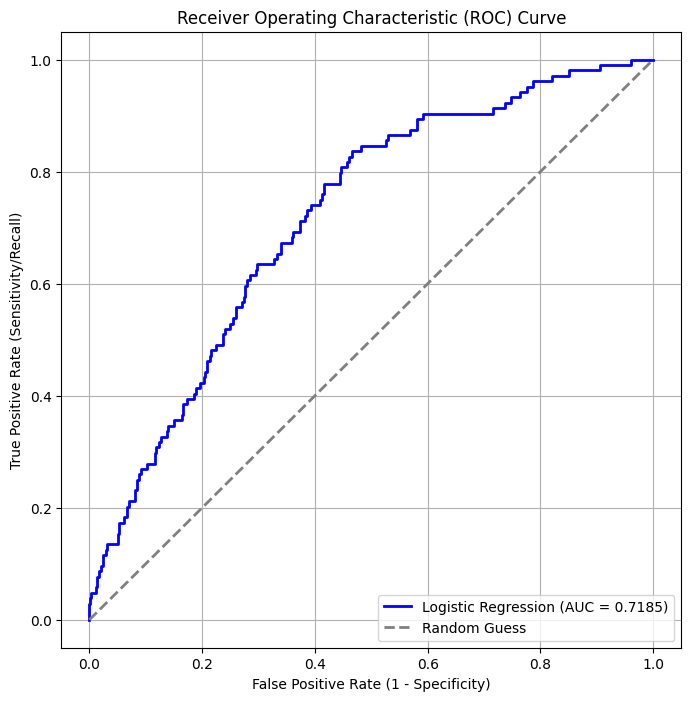

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)

# Plot of the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess') # Add the baseline
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

###Conclusions from the final model evaluation
The ROC AUC score of 0.7185 confirms that the model possesses a respectable ability to distinguish between individuals who are likely to develop Coronary Heart Disease and those who are not, performing significantly better than a random guess.

This overall performance, however, hides a critical trade-off inherent in its predictions. The model's primary strength lies in its high recall, successfully identifying 69% of the patients who actually have the disease. This means that the model is effective at catching a majority of at-risk individuals, minimizing the chance that a high-risk patient is overlooked.

Conversely, this sensitivity comes at the cost of low precision. The model generates a substantial number of false positives (210), meaning many individuals flagged as "at-risk" would not actually go on to develop CHD.

###Model Refinement: Optimizing the Decision Threshold
While this high-recall, low-precision balance is often acceptable for initial screening, the large number of false positives could lead to unnecessary patient anxiety, follow-up testing, and a strain on healthcare resources. Therefore, to make our model more practical for real-world clinical use, our next step will be to move beyond the default 0.5 probability threshold. By analyzing how precision and recall change at different thresholds, we can identify an optimal balance point that better aligns with the goal of creating a reliable and efficient screening tool.

In [ ]:
# Making predictions on the test set
y_predict_probs = final_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Defining a list of thresholds
thresholds = np.arange(0.1, 1.1, 0.1)

# Initialising lists to store results
precisions = []
recalls = []
f1_scores = []

# Calculating metrics for each threshold
for threshold in thresholds:
    y_pred_threshold = (y_predict_probs >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Creating a DataFrame to store results
metrics_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})
metrics_df

,Threshold,Precision,Recall,F1-Score
0,0.1,0.153392,1.000000,0.265985
1,0.2,0.159690,0.990385,0.275033
2,0.3,0.184466,0.913462,0.306947
3,0.4,0.222772,0.865385,0.354331
4,0.5,0.255319,0.692308,0.373057
5,0.6,0.287356,0.480769,0.359712
6,0.7,0.342466,0.240385,0.282486
7,0.8,0.440000,0.105769,0.170543
8,0.9,1.000000,0.009615,0.019048
9,1.0,0.000000,0.000000,0.000000


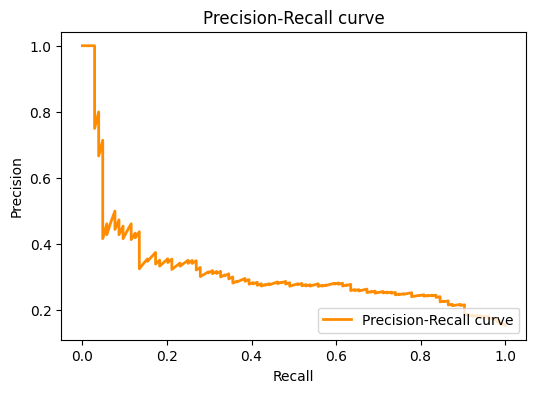

In [ ]:
# Use of precision_recall_curve function to compute the precision, recall and thresholds
precision, recall, thresholds =  precision_recall_curve(y_test, y_predict_probs)

# Plot of the precision-recall curve
plt.figure(figsize=(6,4));
plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve');
plt.xlabel('Recall');
plt.ylabel('Precision');
plt.title('Precision-Recall curve');
plt.legend(loc="lower right");
plt.show();

###Final conclusions from the model evaluation

The goal of this analysis was to determine if we could refine our model's practical performance by moving away from the default 0.5 decision threshold. We hypothesized that we could increase precision (reduce false positives) without a critical loss in recall (the ability to find true cases).

The results, however, reveal the inherent and sharp trade-offs of our current model:

*   Lowering the Threshold: While this strategy dramatically increases recall to over 86% (catching nearly every at-risk patient), it comes at the cost of extremely poor precision (15-22%). This would flood clinicians with an unmanageable number of false alarms, rendering the tool impractical and costly.

*   Increasing the Threshold: As expected, this improves precision. However, the drop in recall is severe and immediate. At a threshold of just 0.6, we would fail to identify more than half of the patients who will actually develop CHD (recall drops to 48%). For a medical screening tool, missing this many cases is unacceptable and defeats its primary purpose.

To objectively identify the best trade-off, we rely on the F1-Score, which represents the harmonic mean of precision and recall. The data clearly shows that the F1-Score is maximized at 0.373 precisely at the 0.5 threshold. Any deviation from this point, either lower or higher, results in a less optimal balance and a lower F1-Score.

Therefore, this analysis was an important validation exercise for our model. It demonstrates that the model's default 0.5 threshold is not arbitrary but is, in fact, the most statistically balanced operating point for this specific model and dataset. The conclusion is that the trade-off we observed is an intrinsic property of the trained model itself.

## 5. Model Interpretation: Identifying Key Risk Factors

For a healthcare application, a prediction is useless without an explanation. We will interpret our final model to understand *which factors* are driving the risk predictions.

-   Since our final model is **Logistic Regression**, we will inspect the model's coefficients (`.coef_`). A large positive coefficient means that an increase in that feature's value strongly increases the predicted log-odds of having CHD.

In [ ]:
# Inspection of the coefficients
print("Model Coefficients:")
print(pd.DataFrame(final_model.coef_.T, index=X_train_scaled.columns, columns=['Coefficient']).sort_values(by='Coefficient', ascending=False))

Model Coefficients:
                 Coefficient
age                 0.484004
sysBP               0.229730
cigsPerDay          0.174856
male                0.152126
glucose             0.151372
prevalentHyp        0.127167
diaBP               0.054732
currentSmoker       0.054115
BPMeds              0.044992
totChol             0.040516
prevalentStroke     0.036138
diabetes            0.030387
BMI                 0.003001
education          -0.056096
heartRate          -0.080684


In [ ]:
#Calculation of the odds ratios by exponentiating the coefficients
odds_ratios = np.exp(final_model.coef_[0])

#Display of the odds ratios in a DataFrame
print("\nModel Odds Ratios:")
print(pd.DataFrame(odds_ratios, index=X_train_scaled.columns, columns=['Odds Ratio']).sort_values(by='Odds Ratio', ascending=False))


Model Odds Ratios:
                 Odds Ratio
age                1.622558
sysBP              1.258260
cigsPerDay         1.191074
male               1.164307
glucose            1.163429
prevalentHyp       1.135607
diaBP              1.056257
currentSmoker      1.055606
BPMeds             1.046020
totChol            1.041348
prevalentStroke    1.036799
diabetes           1.030853
BMI                1.003006
education          0.945448
heartRate          0.922485


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 15 artists>

Text(0.5, 0, 'Logistic Regression Coefficients')

Text(0.5, 1.0, 'Impact of Features on CHD Outcome (Odds Ratio)')

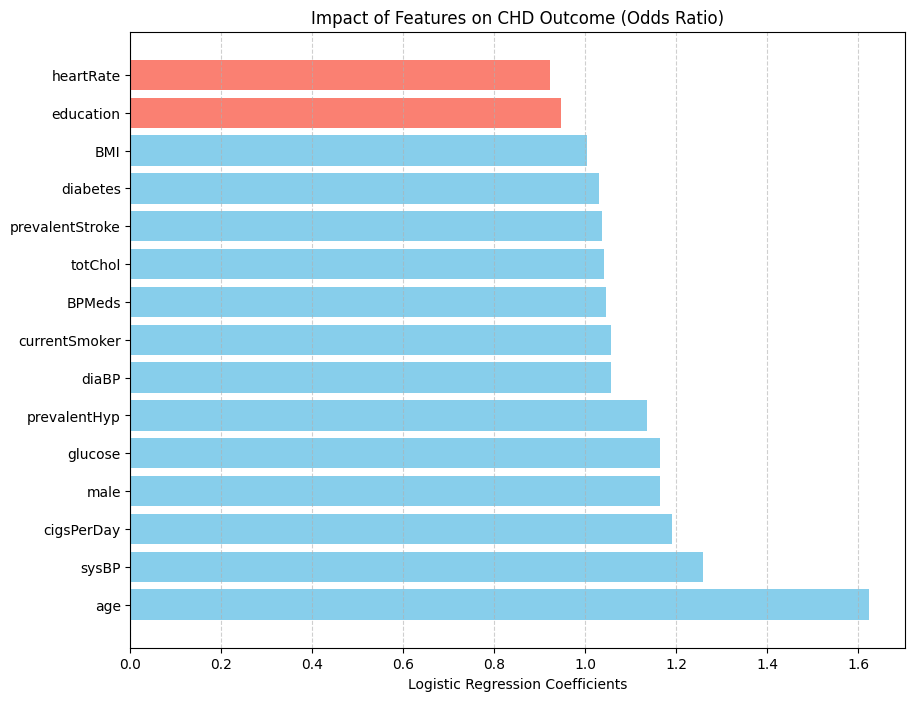

In [ ]:
#Plot of the odds ratios

# Get feature names and odds ratios
feature_names = X_train_scaled.columns
odds_ratios_values = odds_ratios

# Combine into a DataFrame for easier sorting
odds_df = pd.DataFrame({'Feature': feature_names, 'Odds Ratio': odds_ratios_values})

# Sort by odds ratio
odds_df_sorted = odds_df.sort_values(by='Odds Ratio', ascending=False)

# Get sorted feature names and odds ratios
sorted_feature_names = odds_df_sorted['Feature']
sorted_odds = odds_df_sorted['Odds Ratio']

plt.figure(figsize=(10, 8))
plt.barh(sorted_feature_names, sorted_odds, color=['skyblue' if coef > 1 else 'salmon' for coef in sorted_odds])
plt.xlabel('Logistic Regression Coefficients')
plt.title('Impact of Features on CHD Outcome (Odds Ratio)')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

###Conclusions from the model interpretations:

The final model coefficients table brings our project full circle, moving beyond mere prediction to provide the crucial "why" behind the risk scores. This interpretability is the most valuable asset of our Logistic Regression model in a healthcare application. As expected and confirmed by the model, age and sysBP (systolic blood pressure) exhibit the largest positive coefficients, identifying them as the most powerful predictors of 10-year CHD risk. The significant positive coefficient for cigsPerDay provides a stark, quantitative measure of the dangers of smoking.

To make these findings more practical, we converted the coefficients into Odds Ratios. These provide a much more intuitive way to understand risk. For instance, the odds ratio for age (≈1.62) tells us that a standard increase in age raises a patient's odds of developing heart disease by 62%, holding other variables constant. Likewise, a standard increase in systolic blood pressure (sysBP) boosts the odds by 26%.

Beyond confirming well-known risk factors, the model quantifies their specific impact within this dataset.Clinically significant markers like glucose and prevalentHyp (preexisting hypertension) also demonstrate strong positive coefficients, aligning perfectly with established medical knowledge. An interesting nuance is the negative coefficient for education, suggesting a correlation between higher education levels and factors that reduce CHD risk, such as lifestyle choices or health literacy.

##6. Conclusion

###Summary of Key Findings

The project began with a thorough exploratory data analysis (EDA), which identified key challenges such as class imbalance, missing data, and mixed feature types. To address these, a robust preprocessing pipeline was established, incorporating Multivariate Imputation by Chained Equations (MICE) for missing values and standardization of features.

Several classification models were evaluated, including Logistic Regression, K-Nearest Neighbors, Random Forest, and Gradient Boosting. Two strategies for handling the significant class imbalance were tested: using the class_weight='balanced' parameter and the Synthetic Minority Over-sampling Technique (SMOTE).

Ultimately, Logistic Regression with the class_weight='balanced' parameter emerged as the top-performing model, achieving the highest mean ROC AUC score of 0.7248 during cross-validation. This indicates a strong ability to distinguish between patients who will and will not develop CHD. Further hyperparameter tuning using GridSearchCV led to a modest improvement, with the final model achieving a ROC AUC of 0.7273 on the validation set and 0.7185 on the final test set.

The final model demonstrated a high recall of 0.69, successfully identifying 69% of patients who would go on to develop CHD. This is an important strength in a clinical setting, as it minimizes the number of at-risk patients who are missed. However, this came at the cost of a lower precision of 0.26, indicating a significant number of false positives. An analysis of the precision-recall trade-off confirmed that the default 0.5 decision threshold provides the best balance as measured by the F1-Score.

###Limitations

Firstly, the dataset was heavily imbalanced, with only about 15% of individuals developing CHD. While addressed with techniques like class weighting, this imbalance still makes it challenging to achieve high precision without sacrificing recall.

Having said this, the model's high recall is accompanied by low precision, leading to a large number of false positives. In a real-world clinical application, this could lead to unnecessary anxiety and follow-up testing for many patients.

Besides, the predictions were based on a limited set of demographic and clinical features. Other factors not included in the dataset, such as genetics, lifestyle details beyond smoking, and more comprehensive dietary information, could significantly impact the risk of CHD.

Lastly, while a variety of models were tested, the linear nature of Logistic Regression, though interpretable, might not capture all the complex, non-linear interactions between risk factors. More advanced models might offer better performance but at the cost of interpretability.

###Future Work

More sophisticated features could be created from the existing data. For instance, interaction terms between variables (e.g., age and cholesterol) could capture combined effects.

Also, exploring more complex, non-linear models, such as deep neural networks, could potentially improve predictive accuracy. Techniques to maintain interpretability, like SHAP (shapley additive explanations), would be essential if using such models.

The most impactful improvement would likely come from incorporating a wider range of data. This could include genetic markers, detailed physical activity logs, or more granular dietary information.

Regarding external validation, the model should be validated on an independent dataset from a different population to assess its generalizability and robustness.

Finally, while the 0.5 threshold was optimal from a statistical standpoint (F1-Score), future work could involve collaborating with clinicians to determine a threshold that best aligns with clinical workflows and resource constraints, potentially by considering the costs associated with false positives and false negatives.

<a href="https://imgflip.com/i/a00vps"><img src="https://i.imgflip.com/a00vps.jpg" title="made at imgflip.com"/></a><div><a href="https://imgflip.com/memegenerator"></a></div>

In [ ]:
import joblib

# Save the three components to files
joblib.dump(final_model, 'final_model.pkl')
joblib.dump(mice_imputer, 'mice_imputer.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Three files have been saved to your Colab environment:")
print("1. final_model.pkl (your trained model)")
print("2. mice_imputer.pkl (your fitted imputer)")
print("3. scaler.pkl (your fitted scaler)")

['final_model.pkl']

['mice_imputer.pkl']

['scaler.pkl']

Three files have been saved to your Colab environment:
1. final_model.pkl (your trained model)
2. mice_imputer.pkl (your fitted imputer)
3. scaler.pkl (your fitted scaler)
